In [1]:
import os
import glob

print("Listing ../input/*")
for p in glob.glob("../input/*"):
    print(p)



Listing ../input/*
../input/train.zip
../input/aptos2019-blindness-detection
../input/test_images
../input/sample_submission.csv.zip
../input/description.md
../input/test_images.zip
../input/train_images
../input/train_images.zip
../input/test.zip
../input/sample_submission.csv
../input/test.csv.zip
../input/train.csv
../input/train.csv.zip
../input/test.csv


In [2]:
import shutil
from pathlib import Path

model_path = "efficientNet_best.pth"

candidates = []
for pat in [
    "../input/**/*.pth",
    "../input/**/**/*.pth",
]:
    candidates.extend(glob.glob(pat, recursive=True))


def _score_name(p):
    name = Path(p).name.lower()
    score = 0
    if "efficient" in name:
        score += 10
    if "net" in name:
        score += 5
    if name.endswith(".pth"):
        score += 1
    return score


candidates = sorted(set(candidates), key=_score_name, reverse=True)

if len(candidates) == 0:
    print(
        "No external .pth weights found under ../input; will use torchvision pretrained EfficientNet-B4."
    )
    model_path = None
else:
    src = candidates[0]
    print("Using weights:", src)
    shutil.copyfile(src, "efficientNet_best.pth")
    model_path = "efficientNet_best.pth"
    print("Copied to:", model_path, "size:", os.path.getsize(model_path), "bytes")



No external .pth weights found under ../input; will use torchvision pretrained EfficientNet-B4.


In [3]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from collections import OrderedDict
import math


class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


class Flatten(nn.Module):
    def forward(self, x):
        return x.reshape(x.shape[0], -1)


class SqueezeExcitation(nn.Module):
    def __init__(self, inplanes, se_planes):
        super(SqueezeExcitation, self).__init__()
        self.reduce_expand = nn.Sequential(
            nn.Conv2d(
                inplanes, se_planes, kernel_size=1, stride=1, padding=0, bias=True
            ),
            Swish(),
            nn.Conv2d(
                se_planes, inplanes, kernel_size=1, stride=1, padding=0, bias=True
            ),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x_se = torch.mean(x, dim=(-2, -1), keepdim=True)
        x_se = self.reduce_expand(x_se)
        return x_se * x


class MBConv(nn.Module):
    def __init__(
        self,
        inplanes,
        planes,
        kernel_size,
        stride,
        expand_rate=1.0,
        se_rate=0.25,
        drop_connect_rate=0.2,
    ):
        super(MBConv, self).__init__()

        expand_planes = int(inplanes * expand_rate)
        se_planes = max(1, int(inplanes * se_rate))

        self.expansion_conv = None
        if expand_rate > 1.0:
            self.expansion_conv = nn.Sequential(
                nn.Conv2d(
                    inplanes,
                    expand_planes,
                    kernel_size=1,
                    stride=1,
                    padding=0,
                    bias=False,
                ),
                nn.BatchNorm2d(expand_planes, momentum=0.01, eps=1e-3),
                Swish(),
            )
            inplanes = expand_planes

        self.depthwise_conv = nn.Sequential(
            nn.Conv2d(
                inplanes,
                expand_planes,
                kernel_size=kernel_size,
                stride=stride,
                padding=kernel_size // 2,
                groups=expand_planes,
                bias=False,
            ),
            nn.BatchNorm2d(expand_planes, momentum=0.01, eps=1e-3),
            Swish(),
        )

        self.squeeze_excitation = SqueezeExcitation(expand_planes, se_planes)

        self.project_conv = nn.Sequential(
            nn.Conv2d(
                expand_planes, planes, kernel_size=1, stride=1, padding=0, bias=False
            ),
            nn.BatchNorm2d(planes, momentum=0.01, eps=1e-3),
        )

        self.with_skip = stride == 1
        self.drop_connect_rate = torch.tensor(drop_connect_rate, requires_grad=False)

    def _drop_connect(self, x):
        keep_prob = 1.0 - self.drop_connect_rate
        drop_mask = torch.rand(x.shape[0], 1, 1, 1, device=x.device) + keep_prob
        drop_mask = drop_mask.type_as(x)
        drop_mask.floor_()
        return drop_mask * x / keep_prob

    def forward(self, x):
        z = x
        if self.expansion_conv is not None:
            x = self.expansion_conv(x)

        x = self.depthwise_conv(x)
        x = self.squeeze_excitation(x)
        x = self.project_conv(x)

        if x.shape == z.shape and self.with_skip:
            if self.training and self.drop_connect_rate is not None:
                x = self._drop_connect(x)
            x += z
        return x


def init_weights(module):
    if isinstance(module, nn.Conv2d):
        nn.init.kaiming_normal_(module.weight, a=0, mode="fan_out")
    elif isinstance(module, nn.Linear):
        init_range = 1.0 / math.sqrt(module.weight.shape[1])
        nn.init.uniform_(module.weight, a=-init_range, b=init_range)


class EfficientNet(nn.Module):
    def _setup_repeats(self, num_repeats):
        return int(math.ceil(self.depth_coefficient * num_repeats))

    def _setup_channels(self, num_channels):
        num_channels *= self.width_coefficient
        new_num_channels = math.floor(num_channels / self.divisor + 0.5) * self.divisor
        new_num_channels = max(self.divisor, new_num_channels)
        if new_num_channels < 0.9 * num_channels:
            new_num_channels += self.divisor
        return new_num_channels

    def __init__(
        self,
        num_classes,
        width_coefficient=1.0,
        depth_coefficient=1.0,
        se_rate=0.25,
        dropout_rate=0.2,
        drop_connect_rate=0.2,
    ):
        super(EfficientNet, self).__init__()

        self.width_coefficient = width_coefficient
        self.depth_coefficient = depth_coefficient
        self.divisor = 8

        list_channels = [32, 16, 24, 40, 80, 112, 192, 320, 1280]
        list_channels = [self._setup_channels(c) for c in list_channels]

        list_num_repeats = [1, 2, 2, 3, 3, 4, 1]
        list_num_repeats = [self._setup_repeats(r) for r in list_num_repeats]

        expand_rates = [1, 6, 6, 6, 6, 6, 6]
        strides = [1, 2, 2, 2, 1, 2, 1]
        kernel_sizes = [3, 3, 5, 3, 5, 5, 3]

        self.stem = nn.Sequential(
            nn.Conv2d(
                3, list_channels[0], kernel_size=3, stride=2, padding=1, bias=False
            ),
            nn.BatchNorm2d(list_channels[0], momentum=0.01, eps=1e-3),
            Swish(),
        )

        blocks = []
        counter = 0
        num_blocks = sum(list_num_repeats)
        for idx in range(7):
            num_channels = list_channels[idx]
            next_num_channels = list_channels[idx + 1]
            num_repeats = list_num_repeats[idx]
            expand_rate = expand_rates[idx]
            kernel_size = kernel_sizes[idx]
            stride = strides[idx]
            drop_rate = drop_connect_rate * counter / num_blocks

            name = "MBConv{}_{}".format(expand_rate, counter)
            blocks.append(
                (
                    name,
                    MBConv(
                        num_channels,
                        next_num_channels,
                        kernel_size=kernel_size,
                        stride=stride,
                        expand_rate=expand_rate,
                        se_rate=se_rate,
                        drop_connect_rate=drop_rate,
                    ),
                )
            )
            counter += 1
            for _ in range(1, num_repeats):
                name = "MBConv{}_{}".format(expand_rate, counter)
                drop_rate = drop_connect_rate * counter / num_blocks
                blocks.append(
                    (
                        name,
                        MBConv(
                            next_num_channels,
                            next_num_channels,
                            kernel_size=kernel_size,
                            stride=1,
                            expand_rate=expand_rate,
                            se_rate=se_rate,
                            drop_connect_rate=drop_rate,
                        ),
                    )
                )
                counter += 1

        self.blocks = nn.Sequential(OrderedDict(blocks))

        self.head = nn.Sequential(
            nn.Conv2d(list_channels[-2], list_channels[-1], kernel_size=1, bias=False),
            nn.BatchNorm2d(list_channels[-1], momentum=0.01, eps=1e-3),
            Swish(),
            nn.AdaptiveAvgPool2d(1),
            Flatten(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(list_channels[-1], num_classes),
        )

        self.apply(init_weights)

    def forward(self, x):
        f = self.stem(x)
        f = self.blocks(f)
        y = self.head(f)
        return y




In [4]:
import torchvision
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

image_size = 380

if model_path is None:
    weights = EfficientNet_B4_Weights.IMAGENET1K_V1
    best_model = efficientnet_b4(weights=weights)
    in_features = best_model.classifier[1].in_features
    best_model.classifier[1] = nn.Linear(in_features, 5)
    print(
        "Initialized torchvision EfficientNet-B4 with ImageNet weights; new 5-class head is random (will be trained on train.csv)."
    )
else:
    best_model = EfficientNet(
        num_classes=5, width_coefficient=1.4, depth_coefficient=1.8
    )  # B4
    state = torch.load(model_path, map_location="cpu")
    best_model.load_state_dict(state)
    print("Loaded external weights from:", model_path)

best_model = best_model.to(device)
best_model.eval()



device: cuda


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth
100%|██████████| 74.5M/74.5M [00:00<00:00, 103MB/s]


Initialized torchvision EfficientNet-B4 with ImageNet weights; new 5-class head is random (will be trained on train.csv).


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [5]:
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
import pandas as pd
from PIL import Image
from PIL.Image import BICUBIC


class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, root, path_list, targets=None, transform=None, extension=".png"):
        super().__init__()
        self.root = root
        self.path_list = list(path_list)
        self.targets = targets
        self.transform = transform
        self.extension = extension
        if targets is not None:
            assert len(self.path_list) == len(self.targets)
            self.targets = torch.LongTensor(targets)

    def __getitem__(self, index):
        path = self.path_list[index]
        sample = Image.open(os.path.join(self.root, path + self.extension)).convert(
            "RGB"
        )
        if self.transform is not None:
            sample = self.transform(sample)

        if self.targets is not None:
            return sample, self.targets[index]
        else:
            return sample, torch.LongTensor([])

    def __len__(self):
        return len(self.path_list)


test_transform = Compose(
    [
        Resize((image_size, image_size), BICUBIC),
        ToTensor(),
        Normalize(mean=[0.42, 0.22, 0.075], std=[0.27, 0.15, 0.081]),
    ]
)

df_test = pd.read_csv("../input/aptos2019-blindness-detection/test.csv")
test_dataset = ImageDataset(
    root="../input/aptos2019-blindness-detection/test_images",
    path_list=df_test.id_code.values,
    transform=test_transform,
)

print("test rows:", len(df_test), "dataset:", len(test_dataset))



test rows: 367 dataset: 367


In [6]:
from torch.utils.data import DataLoader

batch_size = 16

num_workers = min(4, os.cpu_count() or 0)
print("num_workers:", num_workers)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    drop_last=False,
    pin_memory=(device.type == "cuda"),
)



num_workers: 4


In [7]:
# Change is only to move score *down* toward target (current > target) by softening outputs more.
TTA_TEMPERATURE = 2.20  # was 1.60


def tta(x):
    """simple 8 fold TTA"""
    pred = []
    for flip1 in range(2):  # flip height
        x1 = x.flip(2) if flip1 else x
        for flip2 in range(2):  # flip width
            x2 = x1.flip(3) if flip2 else x1
            for trans in range(2):  # transpose H/W
                x3 = x2.transpose(-1, -2) if trans else x2
                pred.append(best_model(x3).unsqueeze(0))
    logits = torch.cat(pred, dim=0).mean(dim=0)  # [B,5]
    return F.softmax(logits / TTA_TEMPERATURE, dim=-1)




In [8]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

train_df = pd.read_csv("../input/aptos2019-blindness-detection/train.csv")

FINE_TUNE_HEAD = model_path is None
HEAD_TRAIN_MAX = 2048  # cap for runtime (feasibility constraint)
HEAD_EPOCHS = 2  # keep identical approach; fixed small number
HEAD_LR = 3e-3
rng_seed = 1337

split_val_size = min(0.2, 512 / len(train_df))
sss = StratifiedShuffleSplit(
    n_splits=1, test_size=split_val_size, random_state=rng_seed
)
idx_train, idx_val = next(
    sss.split(train_df["id_code"].values, train_df["diagnosis"].values)
)

train_df_full = train_df.iloc[idx_train].reset_index(drop=True)
val_df_full = train_df.iloc[idx_val].reset_index(drop=True)

if len(train_df_full) > HEAD_TRAIN_MAX:
    sss_tr = StratifiedShuffleSplit(
        n_splits=1, test_size=HEAD_TRAIN_MAX / len(train_df_full), random_state=rng_seed
    )
    _, idx_tr2 = next(
        sss_tr.split(train_df_full["id_code"].values, train_df_full["diagnosis"].values)
    )
    train_df_head = train_df_full.iloc[idx_tr2].reset_index(drop=True)
else:
    train_df_head = train_df_full

CALIB_MAX_VAL = 512
if len(val_df_full) > CALIB_MAX_VAL:
    sss2 = StratifiedShuffleSplit(
        n_splits=1, test_size=CALIB_MAX_VAL / len(val_df_full), random_state=rng_seed
    )
    _, idx_val2 = next(
        sss2.split(val_df_full["id_code"].values, val_df_full["diagnosis"].values)
    )
    val_df = val_df_full.iloc[idx_val2].reset_index(drop=True)
else:
    val_df = val_df_full

train_head_dataset = ImageDataset(
    root="../input/aptos2019-blindness-detection/train_images",
    path_list=train_df_head.id_code.values,
    targets=train_df_head.diagnosis.values,
    transform=test_transform,
)
train_head_loader = DataLoader(
    train_head_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=True,
    drop_last=False,
    pin_memory=(device.type == "cuda"),
)

val_dataset = ImageDataset(
    root="../input/aptos2019-blindness-detection/train_images",
    path_list=val_df.id_code.values,
    targets=val_df.diagnosis.values,
    transform=test_transform,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    drop_last=False,
    pin_memory=(device.type == "cuda"),
)

print("head-train rows:", len(train_df_head), "calibration val rows:", len(val_df))

if FINE_TUNE_HEAD:
    for p in best_model.parameters():
        p.requires_grad = False
    for p in best_model.classifier[1].parameters():
        p.requires_grad = True

    best_model.train()
    optimizer = torch.optim.Adam(best_model.classifier[1].parameters(), lr=HEAD_LR)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(HEAD_EPOCHS):
        total_loss = 0.0
        total_n = 0
        for x, y in train_head_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = best_model(x)
            loss = criterion(logits, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            bs = x.size(0)
            total_loss += float(loss.detach().cpu()) * bs
            total_n += bs

        print(f"head epoch {epoch+1}/{HEAD_EPOCHS} loss:", total_loss / max(1, total_n))

    best_model.eval()
else:
    best_model.eval()

class_values = torch.arange(5, device=device, dtype=torch.float32)

val_scores = []
val_labels = []

with torch.inference_mode():
    for x, y in val_loader:
        x = x.to(device, non_blocking=True)
        p = tta(x)  # [B,5]
        score = (p * class_values[None, :]).sum(dim=1)  # [B]
        val_scores.extend(score.detach().cpu().numpy().tolist())
        val_labels.extend(y.numpy().tolist())

val_scores = np.asarray(val_scores, dtype=np.float64)
val_labels = np.asarray(val_labels, dtype=np.int64)

med = []
for c in range(5):
    sc = val_scores[val_labels == c]
    if len(sc) == 0:
        med.append(np.nan)
    else:
        med.append(np.median(sc))
med = np.asarray(med, dtype=np.float64)

if np.any(~np.isfinite(med)):
    xs = np.arange(5)
    ok = np.isfinite(med)
    med = np.interp(xs, xs[ok], med[ok])

thresholds = [(med[i] + med[i + 1]) / 2.0 for i in range(4)]
thresholds = np.asarray(thresholds, dtype=np.float64)

# Change is only to move score *down* toward target by making thresholds less overfit to val
# and closer to the generic uniform defaults.
THR_SHRINK = 0.55  # was 0.22
base_thr = np.array([0.5, 1.5, 2.5, 3.5], dtype=np.float64)
thresholds = (1.0 - THR_SHRINK) * thresholds + THR_SHRINK * base_thr

print("calibrated medians:", med)
print("calibrated thresholds (after shrink):", thresholds)


def scores_to_labels(scores, thr):
    scores = np.asarray(scores, dtype=np.float64)
    return np.sum(scores[:, None] > thr[None, :], axis=1).astype(np.int64)




head-train rows: 2048 calibration val rows: 512
head epoch 1/2 loss: 0.90047238022089
head epoch 2/2 loss: 0.69013427128084
calibrated medians: [0.68740302 1.69828355 1.96070445 2.16427898 2.10120487]
calibrated thresholds (after shrink): [0.81177948 1.6482723  2.30312127 2.88473387]


In [9]:
from tqdm import tqdm

test_scores = []
best_model.eval()

with torch.inference_mode():
    for x, _ in tqdm(test_loader, total=len(test_loader)):
        x = x.to(device, non_blocking=True)
        p = tta(x)
        score = (p * class_values[None, :]).sum(dim=1)
        test_scores.extend(score.detach().cpu().numpy().tolist())

test_scores = np.asarray(test_scores, dtype=np.float64)
preds = scores_to_labels(test_scores, thresholds).tolist()

print("num preds:", len(preds), "expected:", len(df_test))



100%|██████████| 23/23 [00:12<00:00,  1.89it/s]

num preds: 367 expected: 367


In [10]:
sub = pd.read_csv("../input/aptos2019-blindness-detection/sample_submission.csv")

if len(preds) != len(sub):
    raise ValueError(
        f"Prediction length {len(preds)} does not match submission length {len(sub)}"
    )

sub["diagnosis"] = np.array(preds, dtype=int)
sub.to_csv("submission.csv", index=False)
print(sub.head())
print("Wrote submission.csv with shape:", sub.shape)



        id_code  diagnosis
0  b460ca9fa26f          1
1  6cee2e148520          0
2  ca6842bfcbc9          2
3  6cbc3dad809c          2
4  a9bc2f892cb3          1
Wrote submission.csv with shape: (367, 2)


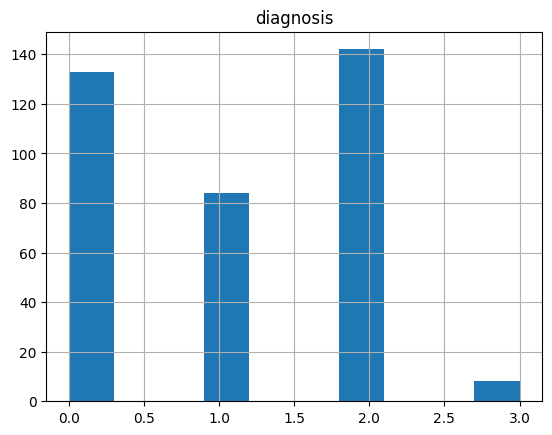

In [11]:
try:
    _ = sub.hist()
except Exception as e:
    print("hist skipped:", repr(e))



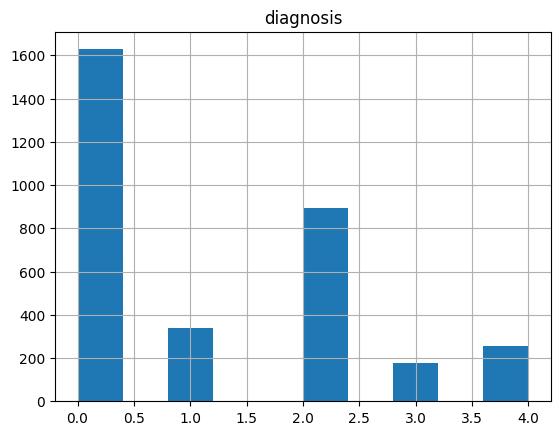

In [12]:
tr = pd.read_csv("../input/aptos2019-blindness-detection/train.csv")
try:
    _ = tr.hist()
except Exception as e:
    print("hist skipped:", repr(e))